In [38]:
from timeit import default_timer as timer
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import SGD
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

In [39]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    x = torch.ones(1, device=device)

    return device

In [40]:
device = get_device()
print(f"device: {device}")

# Umschalten zwischen Colab oder lokaler Installation
USING_COLAB = False
if USING_COLAB:
    from google.colab import drive
    from google.colab.patches import cv2_imshow

    drive.mount("/content/drive")

device: mps


Download and load the training data


In [41]:
def get_data(batch_size: int = 32) -> Tuple[DataLoader, DataLoader]:
    transform = transforms.Compose(
        [
            # Converts to float and normalizes from [0, 255] to [0, 1]
            transforms.ToTensor(),
            # Flattens the 2D image 28x28 to 1D vector 784
            transforms.Lambda(lambda x: x.view(-1)),
        ]
    )

    train_set = datasets.MNIST("data/", download=True, train=True, transform=transform)
    test_set = datasets.MNIST("data/", download=True, train=False, transform=transform)

    train_dl = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(test_set, batch_size=len(test_set), shuffle=False)

    return train_dl, test_dl

Modell (KNN) definieren mit beliebig vielen Schichten, die jeweils variable Anzahl Neuronen beinhalten. Wir beginnen hier immer mit 28x28 Eingabe-Neuronen und müssen am Ende immer auf 10 Ausgabe-Neuronen kommen


In [42]:
def get_model() -> tuple[nn.Module, nn.Module, SGD]:
    model = nn.Sequential(
        nn.Linear(28 * 28, 10),
        # nn.Linear(10, 10),
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer

In [43]:
def init_weights(m: nn.Module):
    if type(m) == nn.Linear:
        # m.weight.data.fill_(1)
        # m.weight.data.uniform_(-0.1, 0.1)
        m.weight.data.normal_(0.0, 0.1)
        if m.bias is not None:
            m.bias.data.fill_(0)

In [44]:
def train_batch(
    x: torch.Tensor, y: torch.Tensor, model: nn.Module, opt: SGD, loss_fn: nn.Module
) -> float:
    model.train()

    prediction = model(x)
    # print(f"prediction.shape {prediction.shape}")

    batch_loss = loss_fn(prediction, y)
    # print(f"batch_loss {batch_loss}")

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()

In [45]:
def accuracy(x: torch.Tensor, y: torch.Tensor, model: nn.Module):
    model.eval()
    with torch.no_grad():
        prediction = model(x)

    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

In [46]:
def loss(x: torch.Tensor, y: torch.Tensor, model: nn.Module, loss_fn: nn.Module):
    model.eval()
    with torch.no_grad():
        prediction = model(x)
        loss = loss_fn(prediction, y)

    return loss.item()

In [52]:
train_dl, test_dl = get_data()
model, loss_fn, optimizer = get_model()

print(len(train_dl.dataset))
print(len(test_dl.dataset))
print(train_dl.dataset.class_to_idx)

60000
10000
{'0 - zero': 0, '1 - one': 1, '2 - two': 2, '3 - three': 3, '4 - four': 4, '5 - five': 5, '6 - six': 6, '7 - seven': 7, '8 - eight': 8, '9 - nine': 9}


In [48]:
# ----------------------------------------------
# Training >>>
#
print("Starting training...")

# Hier werden die initialen Gewichte des Netzes zufällig gesetzt
# model.apply(init_weights)

epochs = 50

arrPlotX = []
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []
for epoch in tqdm(range(epochs)):
    timeBeginEpoch = timer()
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(train_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)
        # print(f"x.shape: {x.shape}  y.shape: {y.shape}\n")

        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(test_dl)):
        x, y = batch
        x, y = x.to(device), y.to(device)

        val_is_correct = accuracy(x, y, model)
        validation_loss = loss(x, y, model, loss_fn)

    val_epoch_accuracy = np.mean(val_is_correct)
    arrPlotX.append(epoch)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    test_losses.append(validation_loss)
    test_accuracies.append(val_epoch_accuracy)
    timeEndEpoch = timer()
    print(
        f"epoch: {epoch}, train_acc: {100 * train_epoch_accuracy:.2f}%, test_acc: {100 * val_epoch_accuracy:.2f}%, took {timeEndEpoch-timeBeginEpoch:.1f}s"
    )

Starting training...


  2%|▏         | 1/50 [00:03<02:53,  3.54s/it]

epoch: 0, train_acc: 83.86%, test_acc: 88.29%, took 3.5s


  4%|▍         | 2/50 [00:07<02:59,  3.74s/it]

epoch: 1, train_acc: 88.45%, test_acc: 89.75%, took 3.9s


...

epoch: 47, train_acc: 92.55%, test_acc: 92.27%, took 3.5s


 98%|█████████▊| 49/50 [02:50<00:03,  3.48s/it]

epoch: 48, train_acc: 92.56%, test_acc: 92.24%, took 3.4s


100%|██████████| 50/50 [02:54<00:00,  3.48s/it]

epoch: 49, train_acc: 92.59%, test_acc: 92.36%, took 3.5s


In [49]:
if USING_COLAB:
    torch.save(
        model.state_dict(),
        "/content/drive/My Drive/ColabNotebooks/results/nnMnist_exp01.pt",
    )
else:
    torch.save(model.state_dict(), "nnMnist_exp01.pt")

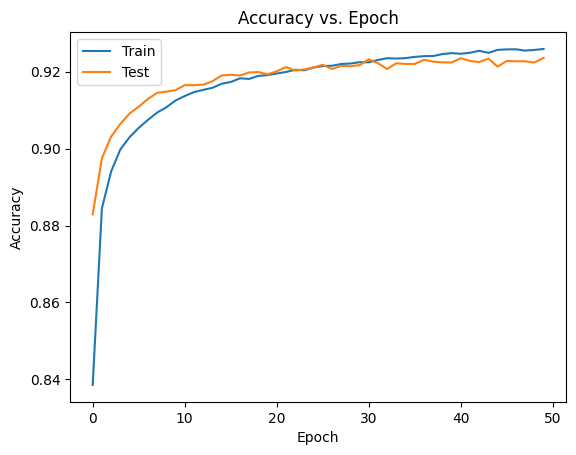

In [50]:
plt.plot(arrPlotX, train_accuracies)
plt.plot(arrPlotX, test_accuracies)
plt.title("Accuracy vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"])

if USING_COLAB:
    plt.savefig("/content/drive/My Drive/ColabNotebooks/results/accuracies_exp0.png")
else:
    plt.savefig("accuracies_exp0.png")

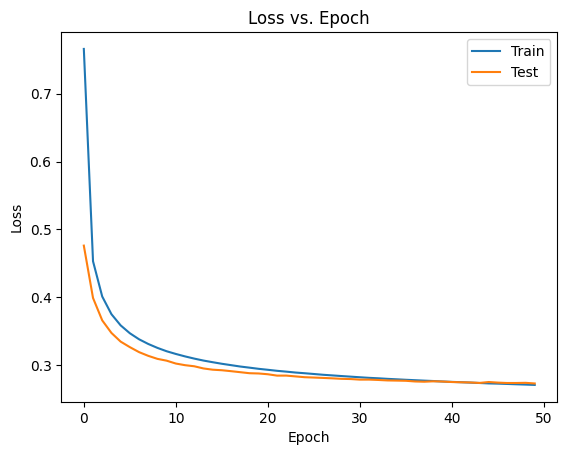

In [51]:
plt.plot(arrPlotX, train_losses)
plt.plot(arrPlotX, test_losses)
plt.title("Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])

if USING_COLAB:
    plt.savefig("/content/drive/My Drive/ColabNotebooks/results/losses_exp0.png")
else:
    plt.savefig("losses_exp0.png")